In [1]:
import os, sys
import pandas as pd
import scanpy as sc
import anndata as ad

from scipy.sparse import issparse

In [2]:
os.chdir('/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/input-data')

#### Define a function to filter based on gene expression, for labelling

In [3]:
import numpy as np
from scipy.sparse import issparse

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold


#### Proceed with the G6 data

In [4]:
g6 = sc.read_h5ad("clustered_egfDuod_G6_DZ_nolog1p.h5ad")

In [5]:
# Make sure leiden is string
g6.obs["leiden"] = g6.obs["leiden"].astype(str)

# Make everything an ISC
g6.obs["manual_label"] = "ISCs"



### Inspect the participants that form our replicates

In [6]:
g6.obs['participant'].unique()

['H329', 'Doublet', 'H897', 'H896', 'Negative']
Categories (5, object): ['Doublet', 'H329', 'H896', 'H897', 'Negative']

In [7]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
g6 = g6[
    ~g6.obs['participant'].isin(removed_participant_labels),
].copy()

### Define the cell type we're analysing; ISCs

In [8]:
cell_type = "ISCs"
sub = g6[g6.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [9]:
sub

AnnData object with n_obs × n_vars = 53206 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [10]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(53206, 28099)
53206 28099


In [11]:
### Don't transpose the matrix,



In [12]:
counts.shape

(53206, 28099)

In [13]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,MIR1302-2HG,AL627309.1,AL627309.5,AL627309.4,AP006222.2,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,...,AC011043.1,AC011043.2,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCAAAGATTCCGA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGCCACGCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGCGAGGTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGCGATGAG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGGATTGCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGGGTCTGT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGGTAGTGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGTACGCCG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGTGAGGAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute our pseudobulk values 

In [14]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


### Transpose the pandas df

In [15]:
pb_counts = pb_counts.T
pb_counts

pb_id,H329_G6,H896_G6,H897_G6
MIR1302-2HG,1.0,1.0,0
AL627309.1,21.0,33.0,23.0
AL627309.5,104.0,141.0,43.0
AL627309.4,0,1.0,0
AP006222.2,1.0,2.0,1.0
...,...,...,...
AC240274.1,292.0,267.0,439.0
AC004556.3,7.0,424.0,13.0
AC136352.3,7.0,8.0,5.0
AC007325.4,37.0,70.0,79.0


In [16]:
pb_counts.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_g6_iscs.csv")

### Repeat for the D10 + Lapatinib data, before merging the pseudobulk dataframes

In [17]:
del g6

In [22]:
d10_lapa = sc.read_h5ad("clustered_egfDuod_D10_Lapa_DZ.h5ad")

In [23]:
d10_lapa

AnnData object with n_obs × n_vars = 33507 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [21]:
d10_lapa.obs

,orig.ident,nCount_RNA,nFeature_RNA,freemuxlet.identity,participant,Condition,Time_point,Treatment,ident,leiden
AAACCAAAGAACGGCA-1,D4_AS,1448.0,905,0,H329,G2D4_AS,G2D4,AS,D4_AS,0
AAACCAAAGAAGCTCC-1,D4_AS,1129.0,758,1,H896,G2D4_AS,G2D4,AS,D4_AS,0
AAACCAAAGCGAAGGC-1,D4_AS,2058.0,1150,Doublet,Doublet,G2D4_AS,G2D4,AS,D4_AS,1
AAACCAAAGCGCTATA-1,D4_AS,2243.0,1367,0,H329,G2D4_AS,G2D4,AS,D4_AS,0
AAACCAAAGCTGGAGA-1,D4_AS,9955.0,3483,Doublet,Doublet,G2D4_AS,G2D4,AS,D4_AS,8
...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGTAGCCGT-1,D4_AS,6607.0,2733,1,H896,G2D4_AS,G2D4,AS,D4_AS,3
TGTGTTGAGTAGCTTG-1,D4_AS,3463.0,1769,0,H329,G2D4_AS,G2D4,AS,D4_AS,10
TGTGTTGAGTAGGTAA-1,D4_AS,6740.0,2600,2,H897,G2D4_AS,G2D4,AS,D4_AS,4
TGTGTTGAGTAGTAAG-1,D4_AS,2755.0,1086,2,H897,G2D4_AS,G2D4,AS,D4_AS,11


In [ ]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d10_lapa = d10_lapa[
    ~d10_lapa.obs['participant'].isin(removed_participant_labels),
].copy()

NameError: name 'd4_as' is not defined

### Define the cell type we're analysing; EECs

In [ ]:
cell_type = "ISCs"
sub = d10_lapa[d10_lapa.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [ ]:
sub

AnnData object with n_obs × n_vars = 6361 × 27680
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(6361, 27680)
6361 27680


In [ ]:
### Don't transpose the matrix,



In [ ]:
counts.shape

(6361, 27680)

In [ ]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,AL627309.1,AL627309.5,AL627309.4,AP006222.2,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,AL645608.2,...,AC011043.1,AC011043.2,AC011841.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCAAAGAACGGCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCATTCACGCACG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCATGCGCTT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTGGACATA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1.0,0,0,0,0,0,0
AAACCCTGTTGCGAGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGGTCAGGGGCTAA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGGTTGTATGGTGA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGGTTGTTGTAACC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0
TGTGTACGTAACTCTA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1.0,0,0,0,0,0


### Compute our pseudobulk values 

In [ ]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


In [ ]:
pb_counts = pb_counts.T
pb_counts

pb_id,H329_G2D4_AS,H896_G2D4_AS,H897_G2D4_AS
AL627309.1,9.0,6.0,2.0
AL627309.5,9.0,23.0,4.0
AL627309.4,1.0,1.0,0
AP006222.2,1.0,1.0,0
LINC01409,73.0,88.0,91.0
...,...,...,...
AC240274.1,42.0,50.0,75.0
AC004556.3,0,34.0,2.0
AC136352.3,0,2.0,1.0
AC007325.4,6.0,13.0,8.0


### Merge the pseudobulk dfs

In [ ]:
original_pb = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_d4_iscs.csv", index_col=0)

In [ ]:
original_pb

,H439_G2D4,H896_G2D4,H897_G2D4
AL627309.1,4.0,15.0,6.0
AL627309.3,1.0,1.0,0.0
AL627309.5,12.0,56.0,14.0
AL627309.4,0.0,0.0,0.0
LINC01409,62.0,162.0,128.0
...,...,...,...
AC240274.1,22.0,98.0,62.0
AC004556.3,1.0,39.0,5.0
AC136352.3,1.0,1.0,1.0
AC007325.4,2.0,2.0,0.0


In [ ]:
pb_counts

pb_id,H329_G2D4_AS,H896_G2D4_AS,H897_G2D4_AS
AL627309.1,9.0,6.0,2.0
AL627309.5,9.0,23.0,4.0
AL627309.4,1.0,1.0,0
AP006222.2,1.0,1.0,0
LINC01409,73.0,88.0,91.0
...,...,...,...
AC240274.1,42.0,50.0,75.0
AC004556.3,0,34.0,2.0
AC136352.3,0,2.0,1.0
AC007325.4,6.0,13.0,8.0


In [ ]:
df_combined = pd.concat([original_pb, pb_counts], axis=1)


In [ ]:
df_combined

,H439_G2D4,H896_G2D4,H897_G2D4,H329_G2D4_AS,H896_G2D4_AS,H897_G2D4_AS
AL627309.1,4.0,15.0,6.0,9.0,6.0,2.0
AL627309.3,1.0,1.0,0.0,NaN,NaN,NaN
AL627309.5,12.0,56.0,14.0,9.0,23.0,4.0
AL627309.4,0.0,0.0,0.0,1.0,1.0,0
LINC01409,62.0,162.0,128.0,73.0,88.0,91.0
...,...,...,...,...,...,...
HSFY2,NaN,NaN,NaN,0,0,1.0
AC007244.1,NaN,NaN,NaN,0,0,0
AC009494.2,NaN,NaN,NaN,0,1.0,0
PRY,NaN,NaN,NaN,0,0,0


In [ ]:
df_combined.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/d4_as_df_combined_iscs.csv")

In [ ]:
df_combined = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/d4_as_df_combined_iscs.csv", index_col=0)

In [ ]:
df_clean = df_combined.fillna(0)
df_clean = df_clean.astype(int)


In [ ]:
counts_df = df_clean.T   # now: rows = samples, cols = genes
counts_df.shape


(6, 28661)

In [ ]:
samples = counts_df.index

condition = ["AS" if "AS" in s else "Dz" for s in samples]
participant = [s.split("_")[0] for s in samples]

clinical_df = pd.DataFrame(
    {
        "condition": condition,
        "participant": participant,
    },
    index=samples,   # IMPORTANT: index must match counts_df.index
)

clinical_df


,condition,participant
H439_G2D4,Dz,H439
H896_G2D4,Dz,H896
H897_G2D4,Dz,H897
H329_G2D4_AS,AS,H329
H896_G2D4_AS,AS,H896
H897_G2D4_AS,AS,H897


### Run pydeseq2

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DESeq dataset
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors="condition",  # use the 'condition' column
)

# fit dispersions + LFCs
dds.deseq2()

# compare Lapa vs Dz
stats = DeseqStats(
    dds,
    contrast=["condition", "AS", "Dz"],  # tested_level, reference_level
)

stats.summary()
res = stats.results_df
res.head()


Using None as control genes, passed at DeseqDataSet initialization


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_5993/717023964.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.13 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 1.35 seconds.

Fitting LFCs...
... done in 0.94 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition AS vs Dz
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   6.418980       -0.370402  0.750975 -0.493228  0.621852  0.710133
AL627309.3   0.378917       -1.902531  3.593001 -0.529510  0.596452       NaN
AL627309.5  16.780835       -0.973753  0.668415 -1.456810  0.145169  0.223295
AL627309.4   0.330752        1.849466  3.672643  0.503579  0.614557       NaN
LINC01409   95.260749       -0.413046  0.240493 -1.717493  0.085889  0.145582
...               ...             ...       ...       ...       ...       ...
HSFY2        0.158137        0.933826  4.437938  0.210419  0.833341       NaN
AC007244.1   0.000000             NaN       NaN       NaN       NaN       NaN
AC009494.2   0.148473        0.933826  4.437938  0.210419  0.833341       NaN
PRY          0.000000             NaN       NaN       NaN       NaN       NaN
AC011841.1   0.148473        0.933826  4.437938  0.210419  0.833341       NaN

[28661

... done in 0.47 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AL627309.1,6.418980,-0.370402,0.750975,-0.493228,0.621852,0.710133
AL627309.3,0.378917,-1.902531,3.593001,-0.529510,0.596452,NaN
AL627309.5,16.780835,-0.973753,0.668415,-1.456810,0.145169,0.223295
AL627309.4,0.330752,1.849466,3.672643,0.503579,0.614557,NaN
LINC01409,95.260749,-0.413046,0.240493,-1.717493,0.085889,0.145582


### Volcano plot

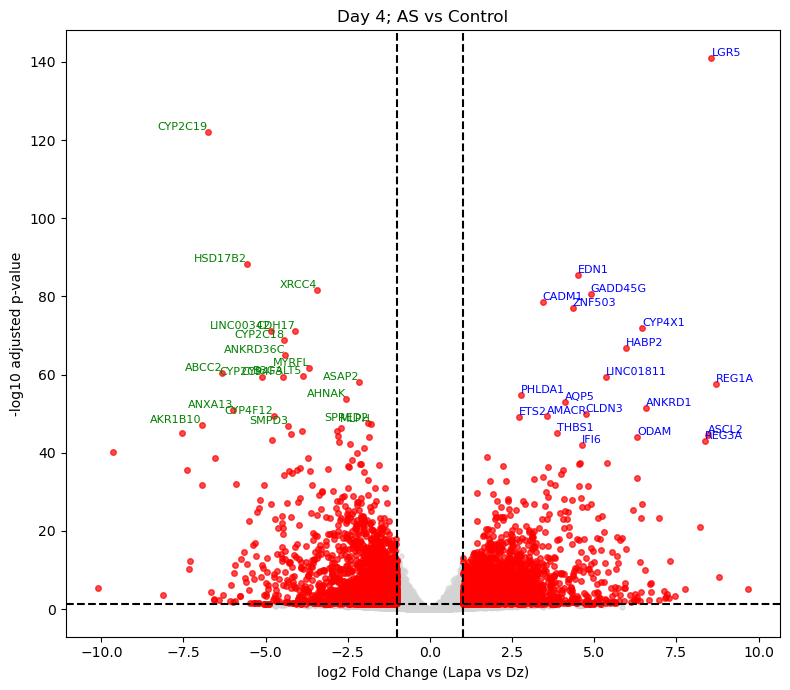

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df = res.copy()
df = df.dropna(subset=["log2FoldChange", "padj"])
df["-log10padj"] = -np.log10(df["padj"])

# ----- define significance (optional) -----
sig = (df["padj"] < 0.05) & (df["log2FoldChange"].abs() > 1)

# ---- select top 20 up-regulated genes ----
top_up = (
    df[df["log2FoldChange"] > 0]
    .sort_values("padj")
    .head(20)
)

# ---- select top 20 down-regulated genes ----
top_down = (
    df[df["log2FoldChange"] < 0]
    .sort_values("padj")
    .head(20)
)

plt.figure(figsize=(8,7))

# ---- plot non-significant ----
plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.6,
    s=12,
)

# ---- plot significant ----
plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.7,
    s=16,
)

# ---- threshold lines ----
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

# ---- label top up-regulated ----
for gene, row in top_up.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="blue",
        ha="left",
        va="bottom"
    )

# ---- label top down-regulated ----
for gene, row in top_down.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="green",
        ha="right",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Lapa vs Dz)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Day 4; AS vs Control")
plt.tight_layout()
plt.show()


In [ ]:
res.to_csv(
    "/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-output/d4_as_iscs_deseq2_results.csv",
    index=True
)